# Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("housing.csv")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
data.dropna(inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


# Data Exploration

In [4]:
from sklearn.model_selection import train_test_split
x = data.drop(['median_house_value'], axis = 1)
y = data['median_house_value']
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [6]:
train_data = x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
10859,-117.87,33.71,16.0,3397.0,686.0,1924.0,621.0,4.9148,<1H OCEAN,155500.0
17709,-121.82,37.33,23.0,3279.0,647.0,2582.0,630.0,4.3782,<1H OCEAN,175800.0
1886,-119.98,38.93,25.0,1262.0,293.0,534.0,226.0,2.6607,INLAND,90400.0
4347,-118.35,34.11,33.0,7478.0,1678.0,2701.0,1500.0,4.1717,<1H OCEAN,500001.0
13704,-117.23,34.11,33.0,2170.0,500.0,1425.0,472.0,2.0133,INLAND,78300.0
...,...,...,...,...,...,...,...,...,...,...
6872,-118.09,34.07,38.0,1036.0,226.0,1058.0,235.0,3.2578,<1H OCEAN,184200.0
6734,-118.10,34.12,49.0,3783.0,579.0,1601.0,539.0,6.3013,<1H OCEAN,500001.0
10052,-121.04,39.19,17.0,856.0,167.0,518.0,170.0,3.5859,INLAND,144300.0
20199,-119.18,34.26,22.0,2334.0,359.0,1298.0,363.0,5.5275,NEAR OCEAN,228900.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

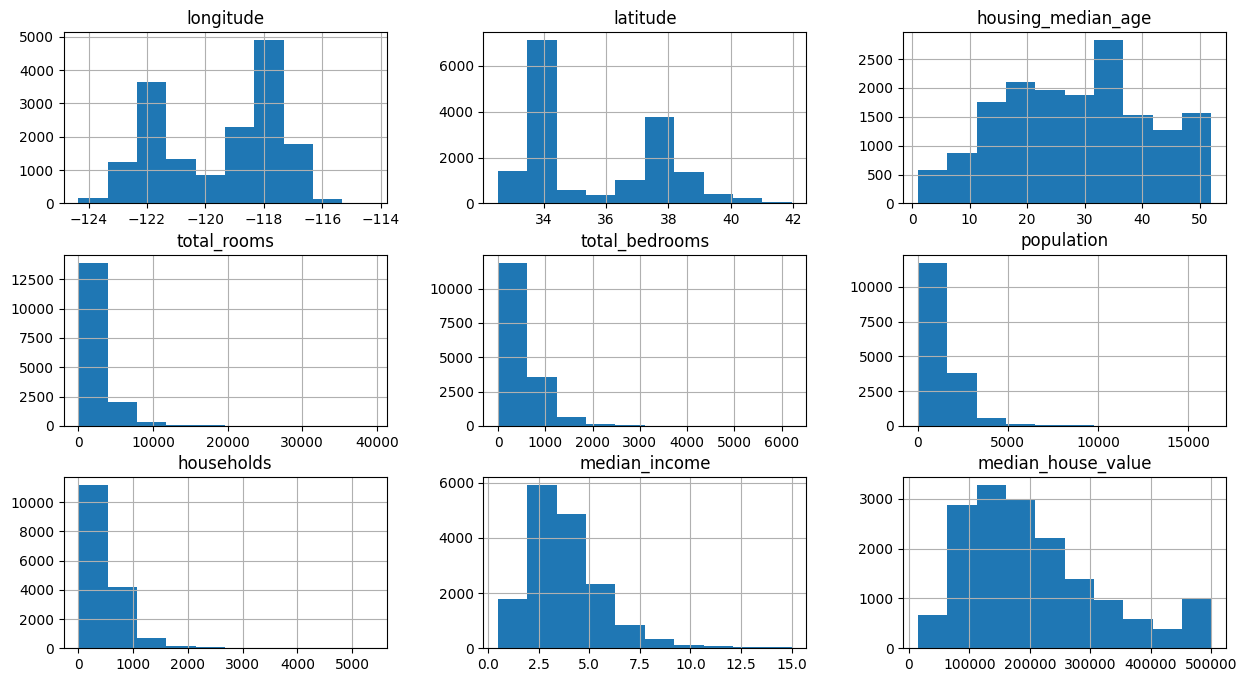

In [7]:
train_data.hist(figsize = (15,8))

In [8]:
train_data.drop(['ocean_proximity'], axis = 1).corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925343,-0.106532,0.050496,0.073244,0.105132,0.059196,-0.016229,-0.044707
latitude,-0.925343,1.000000,0.009073,-0.039563,-0.068366,-0.112834,-0.073132,-0.078241,-0.143057
housing_median_age,-0.106532,0.009073,1.000000,-0.361517,-0.320037,-0.304740,-0.303111,-0.119251,0.105971
total_rooms,0.050496,-0.039563,-0.361517,1.000000,0.930752,0.863360,0.917429,0.197220,0.130695
total_bedrooms,0.073244,-0.068366,-0.320037,0.930752,1.000000,0.884257,0.978197,-0.008468,0.046977
population,0.105132,-0.112834,-0.304740,0.863360,0.884257,1.000000,0.915124,0.008108,-0.027951
households,0.059196,-0.073132,-0.303111,0.917429,0.978197,0.915124,1.000000,0.012921,0.062000
median_income,-0.016229,-0.078241,-0.119251,0.197220,-0.008468,0.008108,0.012921,1.000000,0.684413
median_house_value,-0.044707,-0.143057,0.105971,0.130695,0.046977,-0.027951,0.062000,0.684413,1.000000


<Axes: >

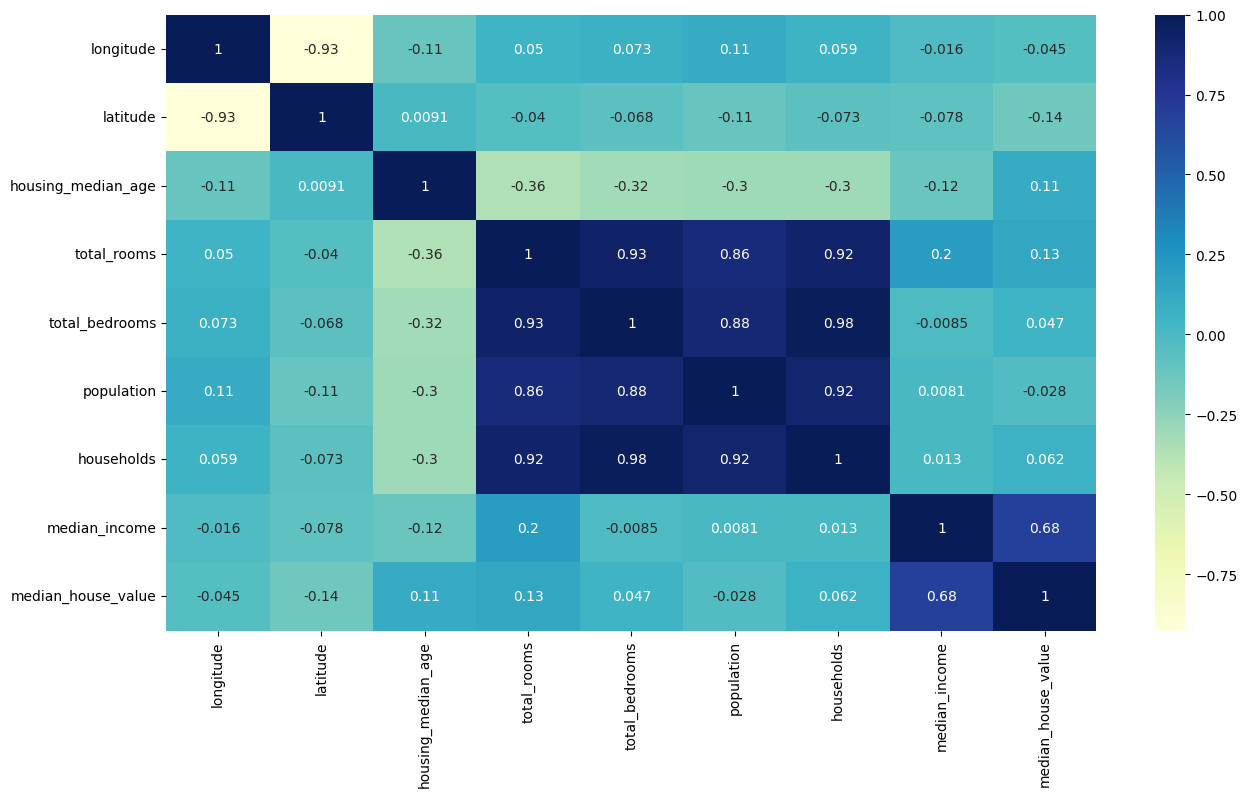

In [9]:
plt.figure(figsize = (15,8))
sns.heatmap(train_data.drop(['ocean_proximity'], axis = 1).corr(), annot = True, cmap = "YlGnBu")

# Data Processing

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

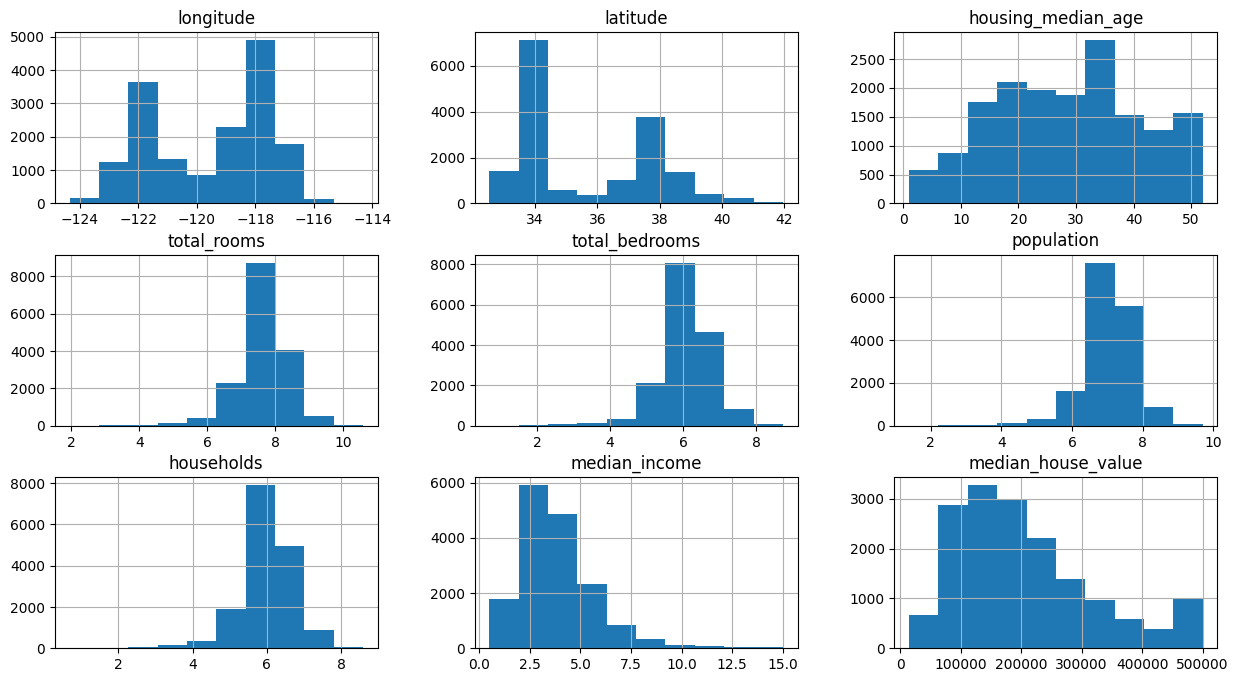

In [10]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)
train_data.hist(figsize = (15,8))

In [11]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7194
INLAND        5210
NEAR OCEAN    2090
NEAR BAY      1850
ISLAND           2
Name: count, dtype: int64

In [12]:
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity'])).drop(['ocean_proximity'], axis = 1)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
10859,-117.87,33.71,16.0,8.130942,6.532334,7.562681,6.432940,4.9148,155500.0,True,False,False,False,False
17709,-121.82,37.33,23.0,8.095599,6.473891,7.856707,6.447306,4.3782,175800.0,True,False,False,False,False
1886,-119.98,38.93,25.0,7.141245,5.683580,6.282267,5.424950,2.6607,90400.0,False,True,False,False,False
4347,-118.35,34.11,33.0,8.919854,7.425954,7.901748,7.313887,4.1717,500001.0,True,False,False,False,False
13704,-117.23,34.11,33.0,7.682943,6.216606,7.262629,6.159095,2.0133,78300.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6872,-118.09,34.07,38.0,6.944087,5.424950,6.965080,5.463832,3.2578,184200.0,True,False,False,False,False
6734,-118.10,34.12,49.0,8.238537,6.363028,7.379008,6.291569,6.3013,500001.0,True,False,False,False,False
10052,-121.04,39.19,17.0,6.753438,5.123964,6.251904,5.141664,3.5859,144300.0,False,True,False,False,False
20199,-119.18,34.26,22.0,7.755767,5.886104,7.169350,5.897154,5.5275,228900.0,False,False,False,False,True


<Axes: >

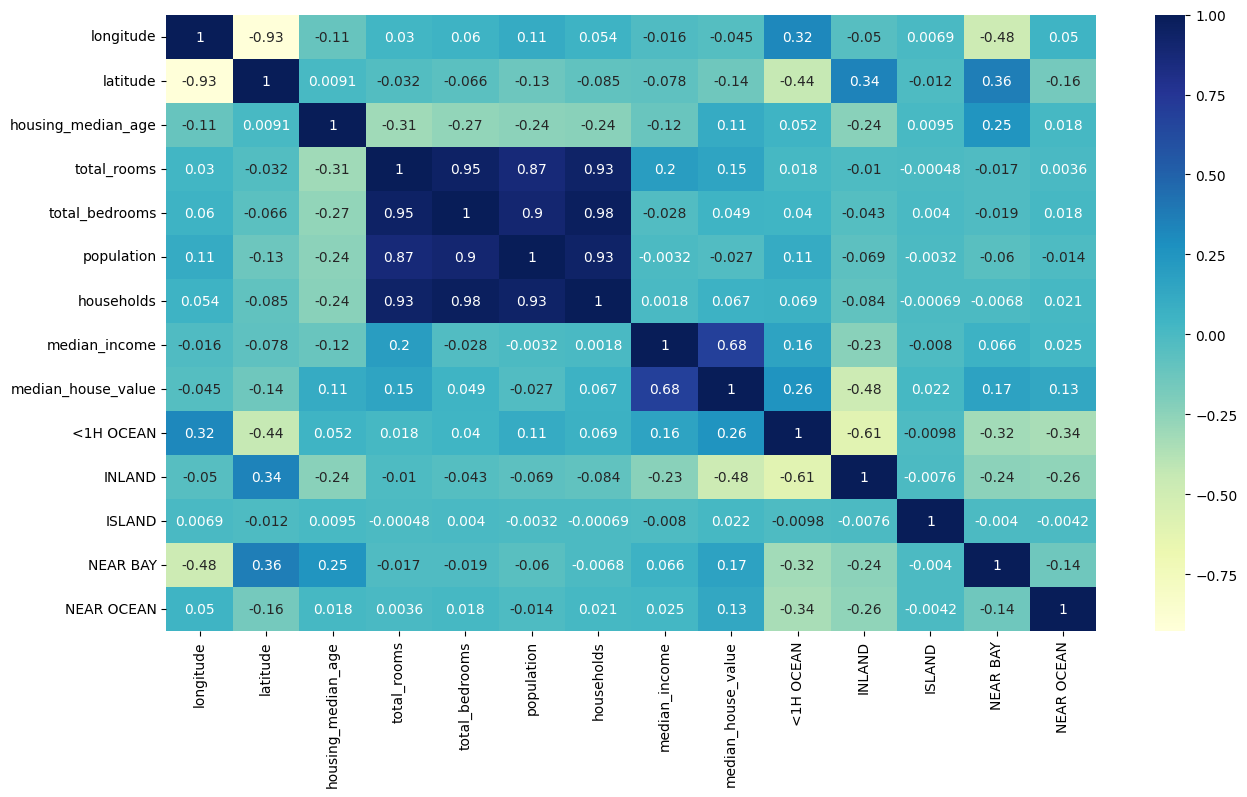

In [13]:
plt.figure(figsize = (15,8))
sns.heatmap(train_data.corr(), annot = True, cmap = "YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

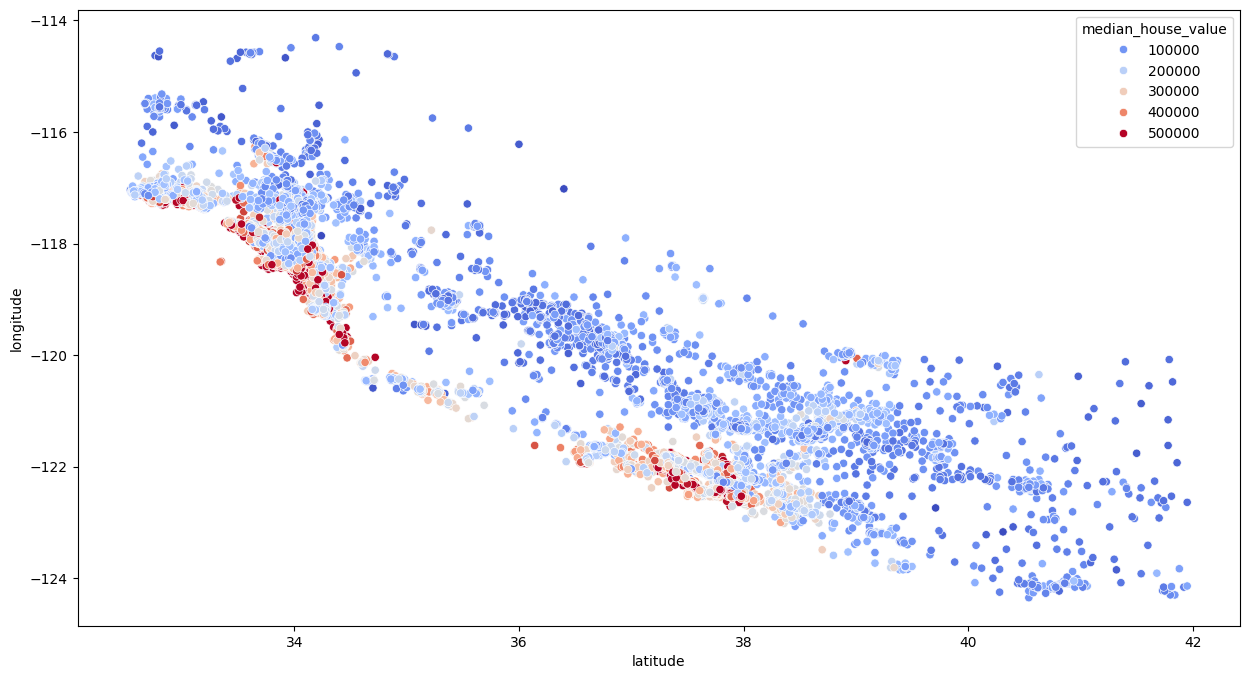

In [14]:
plt.figure(figsize = (15,8))
sns.scatterplot(x = 'latitude', y = 'longitude', data = train_data, hue = 'median_house_value', palette = 'coolwarm')

# Feature Engineering

<Axes: >

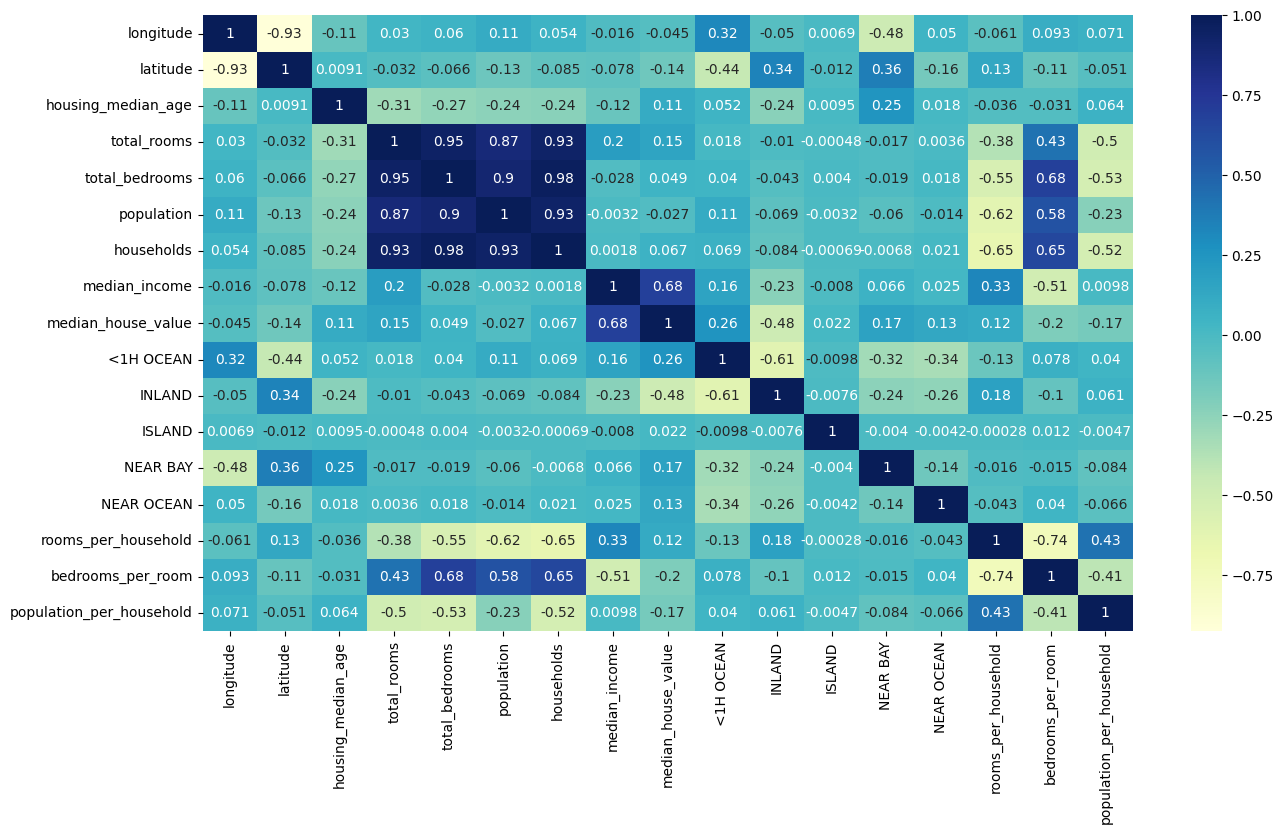

In [15]:
train_data['rooms_per_household'] = train_data['total_rooms'] / train_data['households']
train_data['bedrooms_per_room'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['population_per_household'] = train_data['population'] / train_data['households']
plt.figure(figsize = (15,8))
sns.heatmap(train_data.corr(), annot = True, cmap = "YlGnBu")

# Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train, y_train = train_data.drop(['median_house_value'], axis = 1), train_data['median_house_value']
x_train_s = scaler.fit_transform(x_train)
reg = LinearRegression()
reg.fit(x_train_s, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = (test_data.join(pd.get_dummies(test_data['ocean_proximity'])).drop(['ocean_proximity'], axis=1))

test_data['rooms_per_household'] = test_data['total_rooms'] / test_data['households']
test_data['bedrooms_per_room'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['population_per_household'] = test_data['population'] / test_data['households']
x_test, y_test = test_data.drop(['median_house_value'], axis = 1), test_data['median_house_value']
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
17628,-121.92,37.26,33.0,7.175490,5.560682,6.637258,5.472271,4.5208,230700.0,True,False,False,False,False,1.311245,0.774955,1.212889
18929,-122.14,38.05,27.0,8.241440,6.650279,7.471363,6.586172,3.2891,150600.0,False,False,False,True,False,1.251325,0.806932,1.134402
5141,-118.27,33.96,38.0,6.885510,5.690359,6.979145,5.680173,1.0208,86400.0,True,False,False,False,False,1.212201,0.826425,1.228685
19002,-121.95,38.34,9.0,8.517193,6.774224,7.896553,6.706862,4.2324,142100.0,False,True,False,False,False,1.269922,0.795359,1.177384
72,-122.29,37.81,49.0,6.739337,5.323010,6.329721,5.030438,1.7500,75000.0,False,False,False,True,False,1.339712,0.789842,1.258284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15185,-117.10,32.96,7.0,8.194229,6.647688,7.034388,6.180017,4.1279,167600.0,True,False,False,False,False,1.325923,0.811265,1.138247
8377,-118.35,33.95,30.0,7.886833,6.641182,7.751475,6.586172,3.0519,137500.0,True,False,False,False,False,1.197484,0.842059,1.176932
13953,-117.12,34.21,19.0,8.442901,6.902743,7.196687,6.163315,4.5972,123900.0,False,True,False,False,False,1.369864,0.817580,1.167665
16808,-122.41,37.66,37.0,6.543912,5.241747,6.490724,5.420535,4.6103,237500.0,False,False,False,False,True,1.207245,0.801011,1.197432


In [18]:
x_test_s = scaler.fit_transform(x_test)

In [19]:
reg.score(x_test_s, y_test)

0.6969811730328097

# Random Forest 

In [22]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
forest.score(x_test, y_test)

0.829395762535396

In [31]:
from sklearn.model_selection import GridSearchCV
grid = {'n_estimators': [100, 200, 300], 'max_features': [4,6,8,10]}
grid_search = GridSearchCV(forest, grid, cv = 5, scoring = 'neg_mean_squared_error', return_train_score = True)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [32]:
best_forest = grid_search.best_estimator_
best_forest.score(x_train, y_train)

0.9746891009638632